In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [69]:


data = pd.read_csv('Telco_customer_churn_cleaned.csv')

In [70]:
data.head()

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [71]:
data.drop('Unnamed: 0', axis =1, inplace=True)

In [72]:
#split in X and y
X = data.drop('Churn', axis = 1)
y = data['Churn']

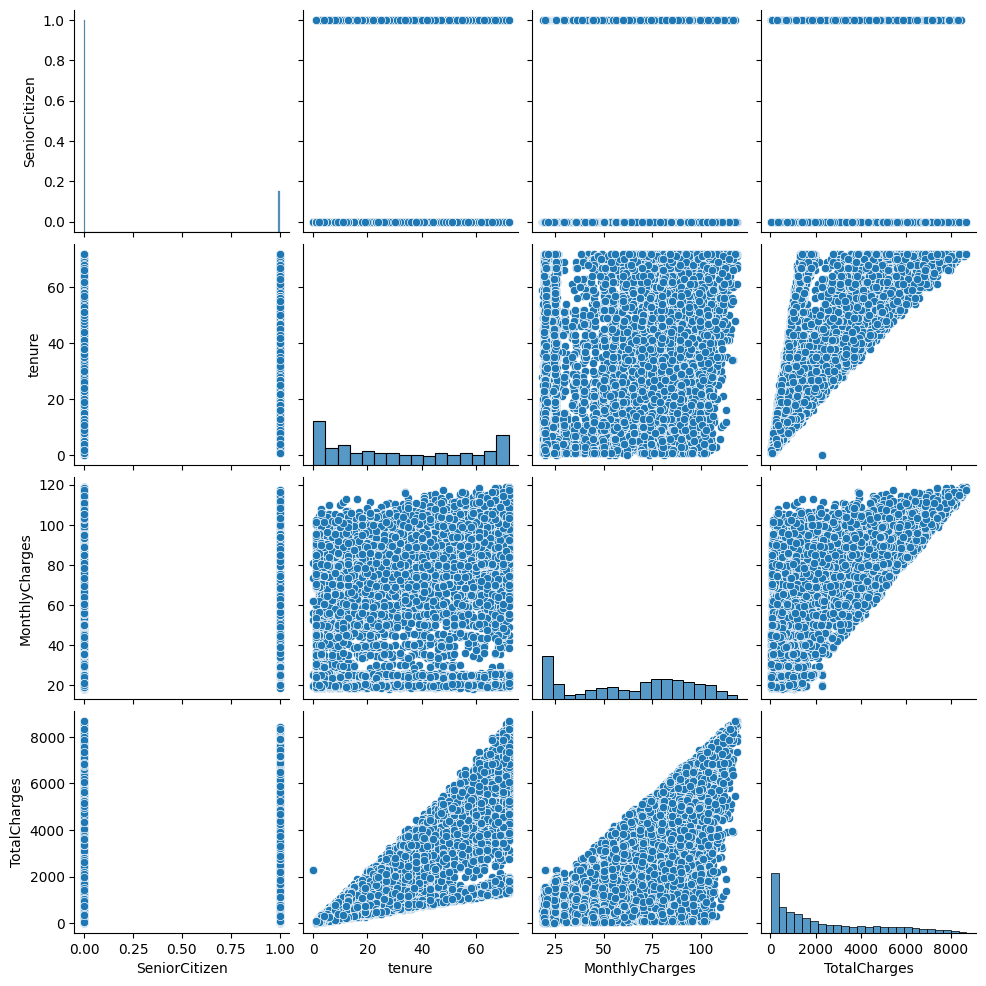

In [73]:
#chekc for multicorrelation
sns.pairplot(X)

#monthly charges and total charges are highly correlated, hence we can drop one
X.drop('MonthlyCharges', axis= 1, inplace= True)

In [74]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  TotalC

In [75]:
#fixing y column
y = [1 if x == 'Yes' else 0 for x in y]


In [76]:
#train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
#onehot encoding and standard scalling on objects
num_featuers = X.select_dtypes(exclude = 'object').columns
obj_features = X.select_dtypes(include= 'object').columns

#initiate transformation

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ohe = OneHotEncoder(drop= 'first')
scaler = StandardScaler()

preprocessor = ColumnTransformer([('OneHotEncoder', ohe, obj_features),
                                  ('StandarScaler', scaler, num_featuers)], remainder= 'passthrough')

In [78]:
obj_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [79]:
#fit and transform data
X_train = preprocessor.fit_transform(X_train)
X_test= preprocessor.transform(X_test)



In [80]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train, y_train)
y_pred = log.predict(X_test) 

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ac = accuracy_score(y_test, y_pred)
cf = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(ac)
print(cf)
print(report)

0.8218594748048261
[[934 102]
 [149 224]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [82]:
#create functin to check accuracy of models

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


def model_evaluator (true, predicted):
    ac = accuracy_score(true, predicted)
    cf = confusion_matrix(true, predicted)
    report = classification_report(true, predicted)

    return ac, cf, report

    

In [86]:
#create list of libraries
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from  xgboost import XGBClassifier

models ={'Logstic Regression': LogisticRegression(),
         'Logsitic Regression Cross validation': LogisticRegressionCV(),
         'support vector classifier': SVC(),
         'KNN classifier': KNeighborsClassifier(),
         'Naive Bias': GaussianNB(),
         'Decision Tree': DecisionTreeClassifier(),
         'Random Forest': RandomForestClassifier(),
         'Adaboost': AdaBoostClassifier(),
         'Gradient Boost': GradientBoostingClassifier(),
         'XgBoost': XGBClassifier()}

In [87]:
#iterate and predict
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    #evaluate models

    X_train_accuracy, X_train_CF, X_train_Report = model_evaluator(y_train, y_pred_train)
    X_test_accuracy, X_test_CF, X_test_Report = model_evaluator(y_test, y_pred_test)

    print(list(models.keys())[i])

    print('-'*20)
    print('for train data')
    print('-'*20)

    print(f'accuracy_score of the model is: ', X_train_accuracy)
    print(f'confusion matrix of  the model is\n:', X_train_CF)
    print(f'classificaiton report of the model is:\n', X_train_Report)

    print('-'*20)
    print('for test data')
    print('-'*20)
    
    print(f'accuracy_score of the model is: ', X_test_accuracy)
    print(f'confusion matrix of  the model is\n:', X_test_CF)
    print(f'classificaiton report of the model is:\n', X_test_Report)


    print('='*30)



Logstic Regression
--------------------
for train data
--------------------
accuracy_score of the model is:  0.80386936457224
confusion matrix of  the model is
: [[3720  418]
 [ 687  809]]
classificaiton report of the model is:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      4138
           1       0.66      0.54      0.59      1496

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.80      0.80      0.80      5634

--------------------
for test data
--------------------
accuracy_score of the model is:  0.8218594748048261
confusion matrix of  the model is
: [[934 102]
 [149 224]]
classificaiton report of the model is:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       

Logistic Regression CV, Gradient Boost, Adaboost, and SVC have good acrruacy on test data, we can hyperparamter tune these models

In [101]:
#hyperparameter tuning
Log_params = {'penalty': ['l1','l2', 'elasticnet'],
                'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
                'max_iter': [10, 20, 30, 50, 100],
                'n_jobs': [-1]}

Gradient_Boost_params = {'learning_rate' : [0.1], 
                         'n_estimators' : [50,100,150],
                         'criterion' : ['friedman_mse', 'squared_error'],
                         'min_samples_split': [1,2,5,10],
                         'max_depth': [2,3,4,5,],
                         'max_features' : [2,4,6]}

adaboost_params = {'n_estimators' : [50,100,150],
                   'learning_rate' : [0.1]}

SVC_prarams = {'C': [.1,1,10,100,1000],
               'gamma': [1, .1, .01,.001, .0001],
               'kernel' : ['linear', 'rbf']}


random_cv_models = [('logistic regression', LogisticRegression(), Log_params),
                    ('gradient boost CV', GradientBoostingClassifier(), Gradient_Boost_params),
                    ('adaboost CV', AdaBoostClassifier(), adaboost_params),
                    ('SVC CV', SVC(), SVC_prarams)]

In [102]:
#passing parameters for new models


from sklearn.model_selection import RandomizedSearchCV

model_params = {}

for name, model, params in random_cv_models:
    random = RandomizedSearchCV( estimator= model,
                                param_distributions= params,
                                n_iter= 100,
                                cv = 3,
                                verbose= 2,
                                n_jobs= -1)
    
    random.fit(X_train, y_train)
    model_params[name] = random.best_params_

    for model_name in model_params:
        print(f'-----------best parameters for {model_name} -----------')
        print(model_params[model_name])

Fitting 3 folds for each of 90 candidates, totalling 270 fits
-----------best parameters for logistic regression -----------
{'solver': 'saga', 'penalty': 'l2', 'n_jobs': -1, 'max_iter': 10}
Fitting 3 folds for each of 100 candidates, totalling 300 fits
-----------best parameters for logistic regression -----------
{'solver': 'saga', 'penalty': 'l2', 'n_jobs': -1, 'max_iter': 10}
-----------best parameters for gradient boost CV -----------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 2, 'max_depth': 3, 'learning_rate': 0.1, 'criterion': 'squared_error'}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
-----------best parameters for logistic regression -----------
{'solver': 'saga', 'penalty': 'l2', 'n_jobs': -1, 'max_iter': 10}
-----------best parameters for gradient boost CV -----------
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 2, 'max_depth': 3, 'learning_rate': 0.1, 'criterion': 'squared_error'}
-----------best parameters for adaboost C

In [103]:
#puttinng tuned parameters in the models and recheck
refined_models = {'Logsitic Regression Cross validation': LogisticRegressionCV(solver = 'saga', penalty = 'l2', n_jobs = -1, max_iter = 10),
         'support vector classifier': SVC(kernel = 'rbf', gamma = 0.01, C = 1),
         'Adaboost': AdaBoostClassifier(n_estimators = 150, learning_rate = 0.1),
         'Gradient Boost': GradientBoostingClassifier(n_estimators = 100, min_samples_split = 2, max_features = 2, max_depth = 3, learning_rate = 0.1, criterion = 'squared_error')
         }

#iterate and predict
for i in range(len(list(refined_models))):
    model = list(refined_models.values())[i]
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    #evaluate models

    X_train_accuracy, X_train_CF, X_train_Report = model_evaluator(y_train, y_pred_train)
    X_test_accuracy, X_test_CF, X_test_Report = model_evaluator(y_test, y_pred_test)

    print(list(models.keys())[i])

    print('-'*20)
    print('for train data')
    print('-'*20)

    print(f'accuracy_score of the model is: ', X_train_accuracy)
    print(f'confusion matrix of  the model is\n:', X_train_CF)
    print(f'classificaiton report of the model is:\n', X_train_Report)

    print('-'*20)
    print('for test data')
    print('-'*20)
    
    print(f'accuracy_score of the model is: ', X_test_accuracy)
    print(f'confusion matrix of  the model is\n:', X_test_CF)
    print(f'classificaiton report of the model is:\n', X_test_Report)


    print('='*30)

Logstic Regression
--------------------
for train data
--------------------
accuracy_score of the model is:  0.8029818956336529
confusion matrix of  the model is
: [[3723  415]
 [ 695  801]]
classificaiton report of the model is:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      4138
           1       0.66      0.54      0.59      1496

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.79      0.80      0.80      5634

--------------------
for test data
--------------------
accuracy_score of the model is:  0.8218594748048261
confusion matrix of  the model is
: [[936 100]
 [151 222]]
classificaiton report of the model is:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg     

Logsitic regression offering best results hence, it is best to pick this model